# Archivist Audit Sampling, EC Modes, and Commitment Schemes

This companion notebook focuses on one design-critical question:

> How many slots (or positions) should we test per audit run, and how does
> that depend on erasure-coding mode and commitment scheme?

The goal is to provide a shareable, engineering-first framework that links:

- audit sample count,
- detection confidence,
- effective detection latency,
- and modeling assumptions used in durability analysis.

Consolidation boundary:

- This notebook owns audit observability assumptions ($\alpha$, touches,
  challenge regimes, and amplification tradeoffs).
- `archivist_reliability_analysis.ipynb` owns CTMC durability estimation and
  uses this notebook's outputs as input assumptions.


## Scope and Assumptions

This notebook does **not** prove protocol security. It offers a practical,
explicit model for comparing audit regimes under clear assumptions.

It also does **not** repeat full CTMC derivations or broad durability sweeps;
those are kept in `archivist_reliability_analysis.ipynb`.

Network-wide Byzantine reserve is handled in the main reliability notebook, not here.

For external reading, treat the scenario values of $\alpha$ in this notebook as
illustrative calibration bands unless a section explicitly ties them to protocol-level
evidence or citations.

Baseline assumptions used here:

- random sampling is unpredictable to the prover,
- sampling rounds are independent enough for exponential-tail approximations,
- a sampled bad position is detected with high probability,
- corruption fraction can be represented as an effective value per regime.
- storage-provider participation is sufficiently decentralized, and request assignment is
  randomized enough that repeated requests do not systematically concentrate on one
  hidden failure domain,
- proof forgery, cross-provider proof collusion, and collusion with the verification
  layer are treated as negligible relative to the inherited security of that layer,
- staking and slashing make detected cheating economically costly.

Under those assumptions, this notebook does not try to enumerate every Byzantine
behavior. On the observability side, adversarial effects are folded into effective inputs
such as $\alpha$, $q_{det}$, or the implied detection hazard.

We intentionally separate:

1. **Recoverability structure** (EC mode),
2. **Audit observability** (what challenges can actually see),
3. **Cryptographic binding** (commitment scheme correctness).


## Environment Setup

This notebook is intended to run outside the internal repo as a standalone
artifact, including on hosted notebook environments such as Google Colab.

The next cell checks the scientific Python stack used by this notebook.
If anything is missing or inconsistent, it refreshes a coherent package bundle
from PyPI and stops with a clear rerun message.


In [21]:
import importlib.util
import subprocess
import sys

AUTO_INSTALL = True

REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

INSTALL_PACKAGES = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
]


def refresh_notebook_stack(reason):
    if not AUTO_INSTALL:
        raise RuntimeError(
            f"Notebook dependencies need refresh ({reason}). Install them with `python -m pip install {' '.join(INSTALL_PACKAGES)}` "
            "or set AUTO_INSTALL=True in this cell."
        )
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--upgrade",
            "--force-reinstall",
            *INSTALL_PACKAGES,
        ]
    )
    raise SystemExit(
        "Refreshed notebook dependencies from PyPI. Restart the runtime or rerun the notebook from the top before continuing. "
        "This is especially important in Google Colab after binary package updates."
    )


missing = [
    pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None
]
if missing:
    refresh_notebook_stack(f"missing packages: {missing}")

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
except Exception as exc:
    refresh_notebook_stack(f"import error: {type(exc).__name__}: {exc}")

print("Environment ready.")


Environment ready.


In [22]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
np.set_printoptions(suppress=True)

AUDIT_EPOCH_HOURS = 24
PLANNING_TARGET_DELTA = 1e-6
PLANNING_TARGET_EPOCHS = 3
ARCHIVIST_TARGET_Q_DET = 1 - 1e-6
RELIABILITY_ANCHOR = {"k": 10, "n": 20, "r0": 1}

TWO_D_CALIBRATION_POINT = {
    "Mode": "2D RS calibration point",
    "Field": "GF(2^16)",
    "Dimensions": 2,
    "Slot target": "1 TB",
    "Data expansion": "2x total/original",
    "Shard size": "256 B",
    "Samples per proof": 160,
    "Target detect prob": ARCHIVIST_TARGET_Q_DET,
    "Shard hashing": "40 KB",
    "Merkle-path hashing": "160 KB",
    "Total SNARK hashing": "200 KB",
    "Primary caveat": "more complexity and weaker adversarial erasure margins than 1D",
    "Source": "https://github.com/logos-storage/logos-storage-research/blob/master/design/proof-erasure-coding.md",
}

print("Environment ready.")


Environment ready.


## Regime Taxonomy: What Exactly Is Being Sampled?

We compare three audit regimes. In this notebook, Regime A is mainly a
reference baseline, not the practical target for large-slot deployments.

- **Regime A: Raw-slot Merkle sampling (reference baseline, no in-slot EC amplification)**
  - Sample random positions in a slot/object committed by a Merkle root.
  - Detection scales with the actual corrupted fraction that sampling can touch.
  - At large slot sizes, this is usually not the preferred design because the
    proof size and verifier CPU can become too large.

- **Regime B: HAIL-like cross-node coded checks**
  - Challenges query coded rows/positions across multiple nodes.
  - Integrity checks leverage cross-node structure; miss probability decays
    quickly with challenge count when corruption is dispersed.

- **Regime C: In-slot coded sampling (e.g., local coded blocks / 2D-like effects)**
  - Sampling is done on coded representation inside a slot.
  - Small physical corruption can map to larger effective detectable damage.
  - A concrete 2D calibration point is added below to anchor this regime in one
    plausible design-note sizing point.

All three regimes produce the same **output interface** for the reliability model:
$(q_{det}, \mathrm{MTTT}_{eff})$. However, how those values are computed differs
fundamentally:

- **Merkle / 2D EC** (single-slot): every audit epoch targets the slot of interest,
  so $\mathrm{MTTT}_{eff} = \tau_{epoch}$ and $q_{det}$ comes from sampling (Merkle)
  or structural guarantees (2D EC).
- **HAIL** (multi-node rotation): audits sample $s_{slots}$ out of $n$ slots per epoch,
  so $\mathrm{MTTT}_{eff} = n \tau_{epoch} / s_{slots}$ and $q_{det}$ comes from
  cross-node amplification.

Regime-specific planning functions below compute $(q_{det}, \mathrm{MTTT}_{eff})$
with the correct math for each case.


## Unified Detection Math

Let:

- $n$ = number of slots for an object,
- $s_{slots}$ = slots sampled per audit epoch,
- $\tau_{epoch}$ = hours per epoch,
- $\alpha$ = **effective detectable bad fraction per touched slot**.

For Archivist-style deployment assumptions, the intended regime is that this
per-touch detectability is very close to one, for example values around
$\alpha \approx q_{det} \approx 1 - 10^{-6}$. In that regime, the dominant
design question is usually slot coverage over time rather than whether one
touch is informative enough.

Quick glossary:

- $\alpha$: per-touch detection probability (how likely one random challenge detects corruption)
- $q_{det}$: per-audit-round detection probability after amplification / multiple touches
- $c$: total effective touches
- $\delta$: residual miss probability after all $c$ touches
- $1 - \delta$: detection confidence
- $\mathrm{MTTT}_{eff}$: how often one slot gets touched on average

So the model has two main audit levers:

- **coverage/cadence**: how often slots get touched
- **touch quality**: how likely one touch is to expose the problem

Then:

- Per-slot proof rate: $\lambda_{proof} = s_{slots}/(n\tau_{epoch})$
- Effective per-slot proof interval: $\mathrm{MTTT}_{eff} = n\tau_{epoch}/s_{slots}$
- Per-touch detection probability: $q_{det}=\alpha$ when each audit round
  consists of a single challenge ($c{=}1$, $m{=}1$, $r{=}1$).
  In general, $q_{det} = 1-(1-\alpha)^{c}$ for Merkle,
  or $q_{det} = 1-(1-\alpha)^{m \cdot r}$ for HAIL amplification.

Effective slot detection hazard:

$$
\lambda_{detect} = \lambda_{proof} q_{det}
$$

For a target miss probability $\delta$ after $c$ independent touches:

$$
c \ge \frac{\ln(\delta)}{\ln(1-\alpha)}
$$

How to read $\delta$:

- $\delta$ is the residual probability that all $c$ touches still miss the problem,
- $1 - \delta$ is the corresponding detection confidence,
- smaller $\delta$ means a stricter audit target and therefore more required touches.

For example, $\delta = 10^{-6}$ means "after the chosen number of touches, the
remaining miss probability is at most one in a million."

Interpretation:

- if $\alpha$ is tiny (worst-case raw data), required touches become large,
- if coding/audit structure increases $\alpha$, required touches drop sharply.

For external readers, the useful Archivist regime is the high-detectability one,
so the summary table below focuses on values close to one.

> **Note on single-slot regimes (Merkle, 2D EC):**  When audits target a specific
> slot every epoch, $s_{slots} = n$ and $\mathrm{MTTT}_{eff} = \tau_{epoch}$.
> The coverage/cadence formulas above still apply — they just simplify to the
> epoch interval.  The multi-slot scaling ($s_{slots} < n$) is only relevant
> for HAIL-like regimes with rotating coverage across nodes.


In [23]:
def required_touches(alpha, delta):
    if alpha <= 0 or alpha >= 1:
        raise ValueError("alpha must be in (0,1)")
    if delta <= 0 or delta >= 1:
        raise ValueError("delta must be in (0,1)")
    ratio = math.log(delta) / math.log1p(-alpha)
    nearest = round(ratio)
    if abs(ratio - nearest) < 1e-9:
        return max(1, int(nearest))
    return math.ceil(ratio)


def mttt_eff_hours(n_slots, slots_per_epoch, epoch_hours):
    if n_slots <= 0 or slots_per_epoch <= 0 or epoch_hours <= 0:
        raise ValueError("all inputs must be positive")
    if slots_per_epoch > n_slots:
        raise ValueError("slots_per_epoch cannot exceed n_slots")
    return n_slots * epoch_hours / slots_per_epoch


def lambda_detect_from_sampling(n_slots, slots_per_epoch, epoch_hours, q_det):
    if q_det < 0 or q_det > 1:
        raise ValueError("q_det must be in [0,1]")
    lambda_proof = slots_per_epoch / (n_slots * epoch_hours)
    return lambda_proof * q_det


def reliability_detection_inputs(n_slots, slots_per_epoch, epoch_hours, q_det):
    mttt_eff = mttt_eff_hours(n_slots, slots_per_epoch, epoch_hours)
    lambda_detect = lambda_detect_from_sampling(
        n_slots, slots_per_epoch, epoch_hours, q_det
    )
    mttd_equiv = math.inf if lambda_detect == 0 else 1 / lambda_detect
    return {
        "MTTT_eff_hours": mttt_eff,
        "lambda_detect_per_hour": lambda_detect,
        "MTTD_equiv_hours": mttd_equiv,
    }


def pct_str(value, decimals=11):
    if value > 0 and (100 * value) < 10 ** (-decimals):
        return f"<{10 ** (-decimals):.{decimals}f}%"
    text = f"{100 * value:.{decimals}f}".rstrip("0").rstrip(".")
    if text in {"", "-0"}:
        text = "0"
    return f"{text}%"


def sci_str(value, decimals=3):
    return f"{value:.{decimals}e}"


def prob_display_str(value, sci_decimals=3, fixed_decimals=6):
    if value > 0.999 and value < 1:
        return f"{value:.{fixed_decimals}f}"
    return sci_str(value, decimals=sci_decimals)


def rate_pct_per_hour_str(rate_per_hour, decimals=11):
    return f"{pct_str(rate_per_hour, decimals=decimals)}/h"


deltas = [1e-2, 1e-4, 1e-6]
alpha_specs = [
    ("0.90", 0.90),
    ("0.99", 0.99),
    ("1 - 1e-4", 1 - 1e-4),
    ("1 - 1e-6", 1 - 1e-6),
]

rows = []
for alpha_label, alpha in alpha_specs:
    row = {"alpha_case": alpha_label, "alpha_effective": alpha}
    for delta in deltas:
        row[f"touches_for_delta_{delta:.0e}"] = required_touches(alpha, delta)
    rows.append(row)

alpha_summary_df = pd.DataFrame(rows)
alpha_summary_df["alpha_effective"] = alpha_summary_df["alpha_effective"].map(
    prob_display_str
)

alpha_summary_df[
    [
        "alpha_case",
        "alpha_effective",
        "touches_for_delta_1e-02",
        "touches_for_delta_1e-04",
        "touches_for_delta_1e-06",
    ]
]


,alpha_case,alpha_effective,touches_for_delta_1e-02,touches_for_delta_1e-04,touches_for_delta_1e-06
0,0.90,9.000e-01,2,4,6
1,0.99,9.900e-01,1,2,3
2,1 - 1e-4,0.999900,1,1,2
3,1 - 1e-6,0.999999,1,1,1


## Alpha Amplification: Effective Levers and Tradeoffs

In this notebook, $\alpha$ is **per-touch detectability**. There are two orthogonal ways
to improve confidence:

1. **Amplify $\alpha$ per touch** (better challenge surface / stronger observation),
2. **Increase number of touches** (more slots sampled or more rounds).

This section focuses on (1).

### Practical levers to amplify $\alpha$

- **In-proof sample multiplicity ($m$)**: ask one proof to cover multiple independent positions.
  - Effect: $\alpha' = 1-(1-\alpha)^m$
  - Cost: larger proof payload and verifier work.

- **Code-aware challenge surface** (stripes/coded symbols instead of raw positions).
  - Effect: increases base detectable fraction per touch.
  - Cost: encoding/update complexity and metadata coupling.

- **Cross-node coupled checks ($r$ nodes per challenge)**.
  - Effect (independent faults approximation): $\alpha' = 1-(1-\alpha)^r$
  - Cost: coordination, network fanout, and committee synchronization overhead.

- **Adaptive risk-weighted sampling** (sample hot/risky slots more aggressively).
  - Effect: raises *effective* $\alpha$ over time for likely-failure regions.
  - Cost: requires telemetry, creates policy complexity, may bias guarantees.

- **Randomness hardening** (unpredictable seeds, commit-reveal/VRF).
  - Effect: preserves realized $\alpha$ against adaptive precomputation.
  - Cost: protocol complexity and potential latency.

### Important distinction

Increasing $s_{slots}$ per epoch does **not** change per-touch $\alpha$; it changes touch
rate $\lambda_{proof}$. In practice, best designs co-optimize both.


### 2D EC

A concrete 2D Reed-Solomon sizing point that is useful for anchoring Regime C.

In the unified model used in this notebook, the cleanest way to import that
design point is to treat one such proof as one effective touch with
$q_{det}$ set to the table's target detect probability.

That does **not** mean every 2D design gets this value automatically. It means this
specific design-note point gives one plausible calibration for the high-detectability
regime used elsewhere in the notebook.


In [24]:
two_d_calibration = pd.DataFrame(
    [
        {
            **TWO_D_CALIBRATION_POINT,
            "Target detect prob": prob_display_str(
                TWO_D_CALIBRATION_POINT["Target detect prob"]
            ),
        }
    ]
)
two_d_calibration


,Mode,Field,Dimensions,Slot target,Data expansion,Shard size,Samples per proof,Target detect prob,Shard hashing,Merkle-path hashing,Total SNARK hashing,Primary caveat,Source
0,2D RS calibration point,GF(2^16),2,1 TB,2x total/original,256 B,160,0.999999,40 KB,160 KB,200 KB,more complexity and weaker adversarial erasure...,https://github.com/logos-storage/logos-storage...


## Touches as a First-Class Control Knob

Yes, confidence depends on detectability $\alpha$, but in operations the most
controllable budget is usually **touches per epoch**.

Define:

- $s_{slots}$: sampled slots per epoch,
- $m$: in-proof multiplicity (subchecks per touched slot),
- $r$: cross-node fanout per challenge,
- $c_{epoch} = s_{slots} \cdot m \cdot r$: effective independent touches per epoch,
- $E$: number of epochs elapsed.

Then cumulative touches are $c = E\,c_{epoch}$ and detection probability is:

$$
P_{detect}(E) = 1 - (1-\alpha)^c = 1 - (1-\alpha)^{E c_{epoch}}
$$

So there are two levers that multiply each other:

- increase $\alpha$ (better per-touch power),
- increase $c_{epoch}$ (more touches per epoch).

In planning terms, you can solve for the minimum touch budget:

$$
c_{needed} \ge \frac{\ln(\delta)}{\ln(1-\alpha)},\qquad
c_{epoch} \ge \left\lceil\frac{c_{needed}}{E}\right\rceil
$$

This is often the cleanest way to size audits against a fixed confidence
target and latency target.


In [ ]:
def touches_per_epoch(s_slots, m=1, r_nodes=1):
    if s_slots < 1 or m < 1 or r_nodes < 1:
        raise ValueError("s_slots, m, r_nodes must be >= 1")
    return s_slots * m * r_nodes


def detection_after_epochs(alpha, c_epoch, epochs):
    if alpha < 0 or alpha > 1:
        raise ValueError("alpha must be in [0,1]")
    if c_epoch < 0 or epochs < 0:
        raise ValueError("c_epoch and epochs must be non-negative")
    c_total = c_epoch * epochs
    return 1 - (1 - alpha) ** c_total


def min_touches_per_epoch(alpha, delta, target_epochs):
    if target_epochs < 1:
        raise ValueError("target_epochs must be >= 1")
    c_needed = required_touches(alpha, delta)
    return math.ceil(c_needed / target_epochs), c_needed


target_epochs = [1, 3, 7, 14]
delta = 1e-6
alpha_values = [0.90, 0.99, 1 - 1e-6]

rows = []
for alpha in alpha_values:
    for E in target_epochs:
        c_epoch_min, c_needed = min_touches_per_epoch(alpha, delta, E)
        rows.append(
            {
                "alpha": alpha,
                "target_epochs": E,
                "delta": delta,
                "touches_needed_total": c_needed,
                "min_touches_per_epoch": c_epoch_min,
            }
        )

touches_budget_df = pd.DataFrame(rows)
touches_budget_df["alpha_sci"] = touches_budget_df["alpha"].map(prob_display_str)
touches_budget_df["alpha_pct"] = touches_budget_df["alpha"].map(pct_str)
touches_budget_df["delta_sci"] = touches_budget_df["delta"].map(sci_str)
touches_budget_df["delta_pct"] = touches_budget_df["delta"].map(pct_str)
touches_budget_df[
    [
        "alpha_sci",
        "alpha_pct",
        "target_epochs",
        "delta_sci",
        "delta_pct",
        "touches_needed_total",
        "min_touches_per_epoch",
    ]
]


,alpha_sci,alpha_pct,target_epochs,delta_sci,delta_pct,touches_needed_total,min_touches_per_epoch
0,9.000e-01,90%,1,1.000e-06,0.0001%,6,6
1,9.000e-01,90%,3,1.000e-06,0.0001%,6,2
2,9.000e-01,90%,7,1.000e-06,0.0001%,6,1
3,9.000e-01,90%,14,1.000e-06,0.0001%,6,1
4,9.900e-01,99%,1,1.000e-06,0.0001%,3,3
5,9.900e-01,99%,3,1.000e-06,0.0001%,3,1
6,9.900e-01,99%,7,1.000e-06,0.0001%,3,1
7,9.900e-01,99%,14,1.000e-06,0.0001%,3,1
8,0.999999,99.9999%,1,1.000e-06,0.0001%,1,1
9,0.999999,99.9999%,3,1.000e-06,0.0001%,1,1


In [26]:
# Example decomposition of the same touch budget into (s_slots, m, r)
# to make operational tradeoffs visible.
target_c_epoch = 20
candidate_plans = [
    {"s_slots": 20, "m": 1, "r_nodes": 1},
    {"s_slots": 10, "m": 2, "r_nodes": 1},
    {"s_slots": 5, "m": 2, "r_nodes": 2},
    {"s_slots": 4, "m": 5, "r_nodes": 1},
]

plan_rows = []
for p in candidate_plans:
    c_epoch = touches_per_epoch(p["s_slots"], p["m"], p["r_nodes"])
    plan_rows.append(
        {
            **p,
            "c_epoch": c_epoch,
            "matches_target": c_epoch == target_c_epoch,
            "relative_proof_work": p["m"],
            "relative_network_fanout": p["r_nodes"],
        }
    )

pd.DataFrame(plan_rows)


,s_slots,m,r_nodes,c_epoch,matches_target,relative_proof_work,relative_network_fanout
0,20,1,1,20,True,1,1
1,10,2,1,20,True,2,1
2,5,2,2,20,True,2,2
3,4,5,1,20,True,5,1


## Sampling Confidence Curves

These curves show how quickly detection confidence saturates once per-touch
detectability is already high.


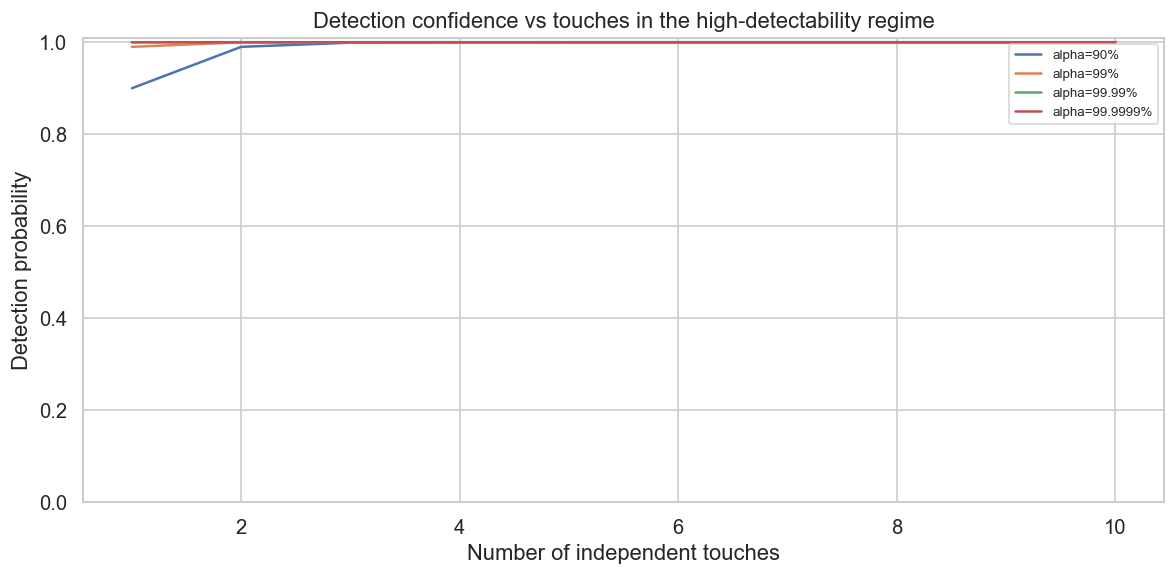

In [27]:
touches = np.arange(1, 11)
alpha_grid = [0.90, 0.99, 1 - 1e-4, 1 - 1e-6]

plt.figure()
for alpha in alpha_grid:
    p_detect = 1 - (1 - alpha) ** touches
    label = f"alpha={pct_str(alpha)}"
    plt.plot(touches, p_detect, label=label)

plt.xlabel("Number of independent touches")
plt.ylabel("Detection probability")
plt.title("Detection confidence vs touches in the high-detectability regime")
plt.ylim(0, 1.01)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Hypergeometric (Finite-Slot) View

For finite sampling without replacement within one audit round:

- $n$ total positions,
- $b$ bad positions,
- $s$ sampled positions.

Exact miss probability in one round:

$$
P_{miss} = \frac{\binom{n-b}{s}}{\binom{n}{s}}
$$

and detect probability is $1-P_{miss}$.

Use the two models as follows:

- use the binomial/exponential-touch approximation when touches accumulate across
  rounds or when the sampled universe is large relative to one round's sample count,
- use the hypergeometric model for one finite round without replacement.

For large populations and modest per-round sample counts, the two are very close.
For small slot universes, the hypergeometric model is the tighter one-round description.


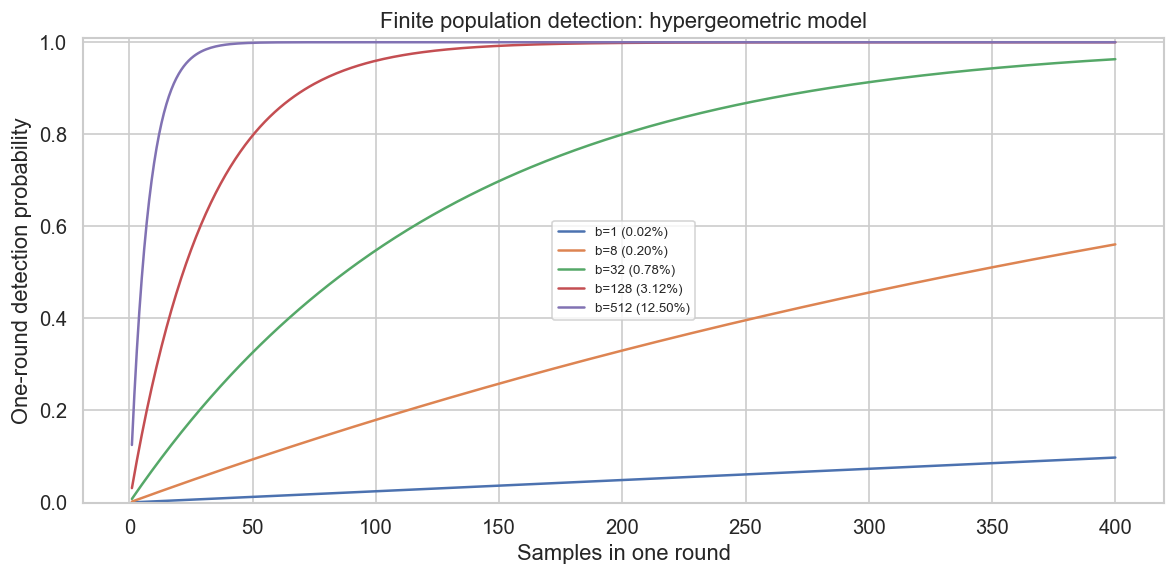

In [28]:
def log_comb(n, k):
    if k < 0 or k > n:
        return float("-inf")
    return math.lgamma(n + 1) - math.lgamma(k + 1) - math.lgamma(n - k + 1)


def detect_prob_hypergeom(n, b, s):
    if n <= 0:
        raise ValueError("n must be positive")
    if b < 0 or b > n:
        raise ValueError("b must satisfy 0 <= b <= n")
    if s < 0:
        raise ValueError("s must be >= 0")
    if b <= 0:
        return 0.0
    if s <= 0:
        return 0.0
    if s > n:
        raise ValueError("s cannot exceed n")
    if s > n - b:
        return 1.0
    log_miss = log_comb(n - b, s) - log_comb(n, s)
    miss = math.exp(log_miss)
    return 1 - miss


n_positions = 4096
sample_sizes = np.arange(1, 401)
bad_counts = [1, 8, 32, 128, 512]

plt.figure()
for b in bad_counts:
    probs = [detect_prob_hypergeom(n_positions, b, s) for s in sample_sizes]
    plt.plot(sample_sizes, probs, label=f"b={b} ({b/n_positions:.2%})")

plt.xlabel("Samples in one round")
plt.ylabel("One-round detection probability")
plt.title("Finite population detection: hypergeometric model")
plt.ylim(0, 1.01)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Illustrative Detectability Bands

Rather than assign exact numeric detectability values to each EC or commitment
design, we use a few **effective detectability bands** as compact proxies:

- lower values correspond to weaker per-touch visibility,
- higher values correspond to stronger per-touch visibility.

The qualitative regime taxonomy above still explains the design space. The
bands below simply show how the unified math behaves as per-touch detectability
approaches one.

These values are illustrative calibration bands, not protocol-derived measurements.

In particular, if Byzantine behavior matters on the observability side, the practical
effect in this framework is to lower effective observability or slow effective detection.


In [29]:
scenario_df = pd.DataFrame(
    [
        {
            "Band": "Conservative high-detectability",
            "alpha_effective": 0.90,
            "Notes": "One touch is informative, but repeated touches still help",
        },
        {
            "Band": "Strong detectability",
            "alpha_effective": 0.99,
            "Notes": "Two or three touches already push miss probability very low",
        },
        {
            "Band": "Very strong detectability",
            "alpha_effective": 1 - 1e-4,
            "Notes": "Per-touch miss probability is already negligible for many uses",
        },
        {
            "Band": "Archivist target regime",
            "alpha_effective": 1 - 1e-6,
            "Notes": "Coverage and cadence dominate because one touch is almost perfectly informative",
        },
    ]
)

for delta in [1e-2, 1e-4, 1e-6]:
    scenario_df[f"touches_for_delta_{delta:.0e}"] = scenario_df["alpha_effective"].map(
        lambda a: required_touches(a, delta)
    )

scenario_df["alpha_effective_sci"] = scenario_df["alpha_effective"].map(prob_display_str)
scenario_df["alpha_effective_pct"] = scenario_df["alpha_effective"].map(pct_str)
scenario_df[[
    "Band", "alpha_effective_sci", "alpha_effective_pct",
    "touches_for_delta_1e-02", "touches_for_delta_1e-04", "touches_for_delta_1e-06",
    "Notes",
]]


,Band,alpha_effective_sci,alpha_effective_pct,touches_for_delta_1e-02,touches_for_delta_1e-04,touches_for_delta_1e-06,Notes
0,Conservative high-detectability,9.000e-01,90%,2,4,6,"One touch is informative, but repeated touches..."
1,Strong detectability,9.900e-01,99%,1,2,3,Two or three touches already push miss probabi...
2,Very strong detectability,0.999900,99.99%,1,1,2,Per-touch miss probability is already negligib...
3,Archivist target regime,0.999999,99.9999%,1,1,1,Coverage and cadence dominate because one touc...


## Mapping to Reliability Inputs (MTTT and Detection Hazard)

This converts audit plans into the quantities used in durability models.

The handoff is direct:

- feed `MTTT_eff_hours` into the reliability notebook as `mttt`,
- feed `q_det` into the reliability notebook as `q_det`.

Each regime computes these via its own planning function:

| Regime | Function | q_det source | MTTT_eff |
|--------|----------|-------------|----------|
| Merkle | `merkle_plan()` | Sampling: $1-(1-\alpha)^c$ | $\tau_{epoch}$ |
| 2D EC | `two_d_plan()` | Structural calibration | $\tau_{epoch}$ |
| HAIL | `hail_plan()` | Amplification: `amplify_alpha` | $n \tau_{epoch} / s_{slots}$ |

Keep the slot universe aligned across notebooks. If a proof touches finer-grained
positions inside one durability-model slot, absorb that amplification into
`q_det` rather than increasing `n_slots`.

To keep the public pair aligned, the concrete plan examples below use the same
shared total-slot anchor configured for the main reliability notebook's standard
anchor object.


In [33]:
anchor_n_slots = RELIABILITY_ANCHOR["n"]
plan_specs = [
    {"Plan": "Full-slot every epoch (HAIL)", "slots_per_epoch": anchor_n_slots},
    {
        "Plan": f"Sample {math.ceil(anchor_n_slots / 2)}/{anchor_n_slots} slots per epoch (HAIL)",
        "slots_per_epoch": math.ceil(anchor_n_slots / 2),
    },
    {
        "Plan": f"Sample {max(1, math.ceil(anchor_n_slots / 4))}/{anchor_n_slots} slots per epoch (HAIL)",
        "slots_per_epoch": max(1, math.ceil(anchor_n_slots / 4)),
    },
]

plans = pd.DataFrame(
    [
        {
            **spec,
            "n_slots": anchor_n_slots,
            "epoch_hours": AUDIT_EPOCH_HOURS,
            "q_det": ARCHIVIST_TARGET_Q_DET,
        }
        for spec in plan_specs
    ]
)

plans[["MTTT_eff_hours", "lambda_detect_per_hour", "MTTD_equiv_hours"]] = plans.apply(
    lambda r: pd.Series(
        reliability_detection_inputs(
            r["n_slots"], r["slots_per_epoch"], r["epoch_hours"], r["q_det"]
        )
    ),
    axis=1,
)

plans["Reliability call"] = plans.apply(
    lambda r: (
        f"model_fail_per_hour(k, n, r0, mttt={r['MTTT_eff_hours']:.1f}, "
        f"mttf, mttr, q_det={r['q_det']:.6f})"
    ),
    axis=1,
)

plans["q_det_sci"] = plans["q_det"].map(prob_display_str)
plans["lambda_detect_per_hour_sci"] = plans["lambda_detect_per_hour"].map(sci_str)
plans["lambda_detect_pct_per_hour"] = plans["lambda_detect_per_hour"].map(
    rate_pct_per_hour_str
)

plans[
    [
        "Plan",
        "n_slots",
        "slots_per_epoch",
        "epoch_hours",
        "q_det_sci",
        "MTTT_eff_hours",
        "lambda_detect_per_hour_sci",
        "lambda_detect_pct_per_hour",
        "MTTD_equiv_hours",
        "Reliability call",
    ]
]


,Plan,n_slots,slots_per_epoch,epoch_hours,q_det_sci,MTTT_eff_hours,lambda_detect_per_hour_sci,lambda_detect_pct_per_hour,MTTD_equiv_hours,Reliability call
0,Full-slot every epoch (HAIL),20,20,24,0.999999,24.0,4.167e-02,4.1666625%/h,24.000024,"model_fail_per_hour(k, n, r0, mttt=24.0, mttf,..."
1,Sample 10/20 slots per epoch (HAIL),20,10,24,0.999999,48.0,2.083e-02,2.08333125%/h,48.000048,"model_fail_per_hour(k, n, r0, mttt=48.0, mttf,..."
2,Sample 5/20 slots per epoch (HAIL),20,5,24,0.999999,96.0,1.042e-02,1.041665625%/h,96.000096,"model_fail_per_hour(k, n, r0, mttt=96.0, mttf,..."


## Practical Decision Procedure

For a target confidence level and target detection latency:

1. Choose the audit regime: Merkle (position sampling), 2D EC (structural),
   or HAIL (cross-node amplification).
2. Use the regime-specific planning function:
   - `merkle_plan(alpha, delta, epoch_hours)` for Merkle,
   - `two_d_plan(epoch_hours, q_det=...)` for 2D EC,
   - `hail_plan(alpha_base, m, r_nodes, n_slots, epoch_hours)` for HAIL.
3. Each returns `q_det`, `MTTT_eff_hours`, and `lambda_detect_per_hour`.
4. Feed `mttt=MTTT_eff_hours` and `q_det=q_det` into the durability notebook for the
   chosen $(k, n, \ell_0, \beta)$ operating point.


In [34]:
def amplify_alpha(alpha_base, m=1, r_nodes=1):
    if not (0 < alpha_base < 1):
        raise ValueError("alpha_base must be in (0,1)")
    if m < 1 or r_nodes < 1:
        raise ValueError("m and r_nodes must be >= 1")
    # Independent-subcheck approximation
    return 1 - (1 - alpha_base) ** (m * r_nodes)


def merkle_q_det(alpha, c):
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1)")

    if c < 1:
        raise ValueError("c must be >= 1")

    return 1 - (1 - alpha) ** c


def merkle_plan(alpha, delta, epoch_hours, target_epochs=PLANNING_TARGET_EPOCHS):
    if not (0 < alpha < 1):
        raise ValueError("alpha must be in (0,1)")

    if epoch_hours <= 0:
        raise ValueError("epoch_hours must be positive")

    c_needed = required_touches(alpha, delta)
    c_per_epoch = math.ceil(c_needed / target_epochs)
    q_det = merkle_q_det(alpha, c_per_epoch)

    return {
        "regime": "Merkle",
        "q_det": q_det,
        "MTTT_eff_hours": epoch_hours,
        "touches_per_epoch": c_per_epoch,
        "touches_needed": c_needed,
        "lambda_detect_per_hour": q_det / epoch_hours,
    }


def two_d_plan(epoch_hours, q_det=ARCHIVIST_TARGET_Q_DET):
    if epoch_hours <= 0:
        raise ValueError("epoch_hours must be positive")

    return {
        "regime": "2D EC",
        "q_det": q_det,
        "MTTT_eff_hours": epoch_hours,
        "lambda_detect_per_hour": q_det / epoch_hours,
    }


def hail_plan(
    alpha_base,
    m,
    r_nodes,
    n_slots,
    epoch_hours,
    delta=PLANNING_TARGET_DELTA,
    target_epochs=PLANNING_TARGET_EPOCHS,
):
    if n_slots <= 0 or epoch_hours <= 0:
        raise ValueError("n_slots and epoch_hours must be positive")
    if m < 1 or r_nodes < 1:
        raise ValueError("m and r_nodes must be >= 1")

    q_det = amplify_alpha(alpha_base, m, r_nodes)
    c_needed = required_touches(q_det, delta)

    # Corrected formula: account for n_slots dilution.
    # Expected touches on target slot per epoch = (slots_per_epoch / n_slots) * m * r_nodes.
    # Need c_needed in target_epochs epochs => slots_per_epoch = ceil(c_needed * n_slots / (target_epochs * m * r_nodes)).
    slots_per_epoch = math.ceil(c_needed * n_slots / (target_epochs * m * r_nodes))

    if slots_per_epoch > n_slots:
        raise ValueError(
            f"Infeasible: need {slots_per_epoch} slots/epoch but only {n_slots} exist. "
            f"Increase target_epochs, m, r_nodes, or alpha_base."
        )

    mttt = mttt_eff_hours(n_slots, slots_per_epoch, epoch_hours)
    lam = lambda_detect_from_sampling(n_slots, slots_per_epoch, epoch_hours, q_det)

    return {
        "regime": "HAIL",
        "q_det": q_det,
        "MTTT_eff_hours": mttt,
        "slots_per_epoch": slots_per_epoch,
        "n_slots": n_slots,
        "c_needed": c_needed,
        "alpha_base": alpha_base,
        "m": m,
        "r_nodes": r_nodes,
        "lambda_detect_per_hour": lam,
    }


# ── Regime-specific examples ──
regime_examples = []

# Merkle example
mp = merkle_plan(alpha=0.90, delta=PLANNING_TARGET_DELTA, epoch_hours=AUDIT_EPOCH_HOURS)
mp["Target"] = "Merkle alpha=90%"
regime_examples.append(mp)

# 2D EC example
tdp = two_d_plan(epoch_hours=AUDIT_EPOCH_HOURS)
tdp["Target"] = "2D EC (structural)"
regime_examples.append(tdp)

# HAIL examples
# With the corrected n_slots scaling, low alpha + small m*r may be infeasible
# on a small slot universe. These examples use m*r >= 2 to stay feasible.
for label, alpha, m, r in [
    ("HAIL alpha=90% m=2 r=2", 0.90, 2, 2),
    ("HAIL alpha=99% m=1 r=1", 0.99, 1, 1),
    ("HAIL alpha=1-1e-6 m=1 r=1", ARCHIVIST_TARGET_Q_DET, 1, 1),
]:
    hp = hail_plan(
        alpha_base=alpha,
        m=m,
        r_nodes=r,
        n_slots=RELIABILITY_ANCHOR["n"],
        epoch_hours=AUDIT_EPOCH_HOURS,
    )
    hp["Target"] = label
    regime_examples.append(hp)

examples_df = pd.DataFrame(regime_examples).set_index("Target")
display_cols = [
    c
    for c in [
        "regime",
        "q_det",
        "MTTT_eff_hours",
        "lambda_detect_per_hour",
        "slots_per_epoch",
        "n_slots",
        "c_needed",
        "touches_per_epoch",
        "touches_needed",
        "alpha_base",
        "m",
        "r_nodes",
    ]
    if c in examples_df.columns
]
examples_df[display_cols]


,regime,q_det,MTTT_eff_hours,lambda_detect_per_hour,slots_per_epoch,n_slots,c_needed,touches_per_epoch,touches_needed,alpha_base,m,r_nodes
Target,,,,,,,,,,,,
Merkle alpha=90%,Merkle,0.990000,24.000000,0.041250,NaN,NaN,NaN,2.0,6.0,NaN,NaN,NaN
2D EC (structural),2D EC,0.999999,24.000000,0.041667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HAIL alpha=90% m=2 r=2,HAIL,0.999900,120.000000,0.008332,4.0,20.0,2.0,NaN,NaN,0.900000,2.0,2.0
HAIL alpha=99% m=1 r=1,HAIL,0.990000,24.000000,0.041250,20.0,20.0,3.0,NaN,NaN,0.990000,1.0,1.0
HAIL alpha=1-1e-6 m=1 r=1,HAIL,0.999999,68.571429,0.014583,7.0,20.0,1.0,NaN,NaN,0.999999,1.0,1.0


## Deployment-Specific Inputs and Assumptions

- Effective detectability assumptions ($\alpha$ or $q_{det}$) should be tied to protocol specifics.
- Independence assumptions across rounds should match the intended adversary model.
- The audit slot universe should match the durability-model slot universe.
- Correlated-failure effects (node-level or time-local) should be assessed separately from the baseline model.
- Detection confidence and recoverability guarantees should be interpreted as distinct quantities.
- For any concrete deployment, state clearly whether Byzantine effects are already absorbed
  into conservative effective values of $\alpha$, $q_{det}$, or proof cadence.